# Part 2: Cross-Domain Acne Classification

**Self-contained Colab notebook** — no need to run Part 1 first.

Train a binary **acne vs clear-skin** classifier on **ACNE04 patches** (ResNet-50), then evaluate on **DermNet** with test-time domain adaptation and Grad-CAM.

**Before you start**
- Runtime → **GPU** (T4 is enough; ~30–60 min end-to-end)
- Free [Roboflow API key](https://app.roboflow.com/settings/api) (ACNE04 download)
- [Kaggle API token](https://www.kaggle.com/settings) (`kaggle.json`) for DermNet

**Test-time adaptation ablation** (same trained weights; varies preprocessing only):
1. Baseline (`da=none`)
2. + Histogram matching
3. + Reinhard color normalization
4. + Reinhard + TTA (horizontal flip)

## 0. Setup

Link: https://github.com/nprakash1/acne_yang_project/tree/main/part2_classification

In [1]:
# Auto-detect how the project got into this Colab runtime.
# Supports three workflows -- you don't have to edit anything:
#   (1) git clone   - set GITHUB_URL below to a public repo URL
#   (2) zip upload  - drag acne_yang_project.zip into Colab's file pane
#   (3) Drive copy  - put the unzipped folder anywhere in your Drive
import os, glob, subprocess

GITHUB_URL = 'https://github.com/nprakash1/acne_yang_project.git'
PROJECT_DIR = 'acne_yang_project'

def _is_project_root(p):
    return os.path.isdir(os.path.join(p, 'part2_classification')) and \
           os.path.isfile(os.path.join(p, 'requirements.txt'))

# Already at project root?
if _is_project_root('.'):
    print('[setup] already at project root')
elif os.path.isdir(PROJECT_DIR) and _is_project_root(PROJECT_DIR):
    %cd $PROJECT_DIR
    print(f'[setup] cd into ./{PROJECT_DIR}')
else:
    zips = glob.glob('/content/*.zip') + glob.glob('./*.zip')
    drive_hits = glob.glob('/content/drive/MyDrive/**/part2_classification', recursive=True)
    if zips:
        z = zips[0]
        print(f'[setup] unzipping {z}')
        subprocess.check_call(['unzip', '-q', '-o', z, '-d', '/content/_extracted'])
        roots = [r for r, _, _ in os.walk('/content/_extracted') if _is_project_root(r)]
        assert roots, 'zip did not contain a project root (part2_classification/ + requirements.txt)'
        %cd $roots[0]
    elif drive_hits:
        root = os.path.dirname(drive_hits[0])
        print(f'[setup] using project from Drive: {root}')
        %cd $root
    elif GITHUB_URL:
        print(f'[setup] cloning {GITHUB_URL}')
        subprocess.check_call(['git', 'clone', GITHUB_URL])
        %cd $PROJECT_DIR
    else:
        raise RuntimeError(
            'No project source found. Either:\n'
            ' - set GITHUB_URL above to your repo, or\n'
            ' - drag acne_yang_project.zip into the Colab file pane and re-run, or\n'
            ' - mount Drive with the project folder inside MyDrive.'
        )

print('[setup] cwd =', os.getcwd())
!pip install -q -r requirements.txt
print('[setup] dependencies installed')

[setup] cloning https://github.com/nprakash1/acne_yang_project.git
/content/acne_yang_project
[setup] cwd = /content/acne_yang_project
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.8/7.8 MB 76.3 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 25.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.9/207.9 kB 23.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.9/49.9 MB 47.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.8/66.8 kB 8.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 87.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 72.2 MB/s eta 0:00:00
[setup] dependencies installed


### GPU check (optional Drive)

Enable **Runtime → Change runtime type → GPU** before training.

In [2]:
import torch
print('CUDA available:', torch.cuda.is_available())
if torch.cuda.is_available():
    print('GPU:', torch.cuda.get_device_name(0))
else:
    print('WARNING: no GPU — training will be very slow. Enable GPU in Runtime settings.')

# Optional: mount Drive to persist outputs across sessions
try:
    from google.colab import drive
    drive.mount('/content/drive')
except Exception:
    pass

CUDA available: True
GPU: NVIDIA A100-SXM4-40GB
Mounted at /content/drive


## 1. Download ACNE04 (COCO format)

Patches are built from detection bounding boxes. We only need the **COCO** export (not YOLO).

Get a free API key at https://app.roboflow.com/settings/api — paste when prompted, or set Colab secret `ROBOFLOW_API_KEY`.

In [3]:
import os
from getpass import getpass
from pathlib import Path

COCO_ANN = Path('data/acne04/coco/train/_annotations.coco.json')

if COCO_ANN.exists():
    print('[data] ACNE04 COCO already present:', COCO_ANN.parent.parent)
else:
    if not os.environ.get('ROBOFLOW_API_KEY'):
        try:
            from google.colab import userdata
            os.environ['ROBOFLOW_API_KEY'] = userdata.get('ROBOFLOW_API_KEY')
        except Exception:
            pass
    if not os.environ.get('ROBOFLOW_API_KEY'):
        os.environ['ROBOFLOW_API_KEY'] = 'c1orEQIdQdZYPwUiFe2I'
    from part1_detection.data import download_acne04
    coco_root = download_acne04(out_dir='data/acne04', fmt='coco')
    print('[data] COCO root:', coco_root)

assert COCO_ANN.exists(), f'missing {COCO_ANN} — check Roboflow download'

loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to /content/acne_yang_project/data/acne04/coco in coco:: 100%|██████████| 3406/3406 [00:00<00:00, 7032.14it/s]


[data] COCO root: /content/acne_yang_project/data/acne04/coco


## 2. Generate ACNE04 patches

In [4]:
from pathlib import Path
import shutil
from part2_classification.make_patches import make_patches

PATCH_ROOT = Path('data/acne04_patches')
required_dirs = [PATCH_ROOT / split / cls for split in ('train', 'val', 'test') for cls in ('pos', 'neg')]
patches_complete = all(d.exists() and any(d.glob('*.jpg')) for d in required_dirs)
# Rebuild if you previously generated the old close-up-only patches.
FORCE_REBUILD_PATCHES = True  # keep True once after changing crop settings; set False after regeneration

if patches_complete and not FORCE_REBUILD_PATCHES:
    print('[patches] train/val/test already built at', PATCH_ROOT.resolve())
else:
    if PATCH_ROOT.exists():
        print('[patches] removing incomplete old patch folder so train/val/test are consistent')
        shutil.rmtree(PATCH_ROOT)
    # Tier-1 patch generation:
    #   - multi-scale positives + absolute min crop sides so tiny GT boxes
    #     become real wide-context crops, not just upsampled close-ups
    #   - texture-biased negatives (Sobel-energy weighted) so the negative
    #     class includes noses, lips, eyebrows, hair, stubble -- not just
    #     smooth cheek/forehead like the old uniform sampler
    counts = make_patches(
        coco_root='data/acne04/coco',
        out_root=str(PATCH_ROOT),
        expand_scales=[1.5, 2.5, 4.0],
        positive_min_sides=[64, 128, 256],
        target_size=224,
        neg_per_pos=1.0,
        neg_sampling='texture',
    )
    print(counts)


[train] pos=119142  neg=67403
[val] pos=10269  neg=5849
[test] pos=5211  neg=2884
{'train': {'pos': 119142, 'neg': 67403}, 'val': {'pos': 10269, 'neg': 5849}, 'test': {'pos': 5211, 'neg': 2884}}


### Visual sanity check: ACNE04 patches

Positive examples are crops around acne GT boxes. Negative examples are random clear-skin crops with zero overlap to GT boxes.

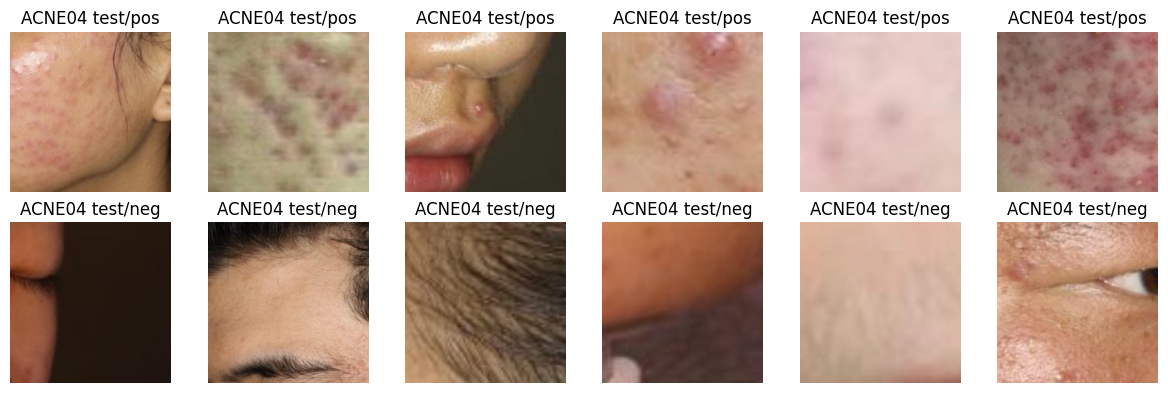

In [5]:
import random
import matplotlib.pyplot as plt
from PIL import Image

rng = random.Random(0)
fig, axes = plt.subplots(2, 6, figsize=(12, 4))
for row, cls_name in enumerate(['pos', 'neg']):
    paths = sorted((PATCH_ROOT / 'test' / cls_name).glob('*.jpg'))
    sample = rng.sample(paths, min(6, len(paths)))
    for ax, p in zip(axes[row], sample):
        ax.imshow(Image.open(p).convert('RGB'))
        ax.set_title(f'ACNE04 test/{cls_name}')
        ax.axis('off')
plt.tight_layout()

## 3. Download DermNet (Kaggle)

Upload `kaggle.json` when prompted (from https://www.kaggle.com/settings → **Create New Token**), or place it in `~/.kaggle/` before running.

In [6]:
import os
from pathlib import Path

DERMNET_ROOT = Path('data/dermnet')
TRAIN_DIR = DERMNET_ROOT / 'train'
TEST_DIR = DERMNET_ROOT / 'test'

if TRAIN_DIR.is_dir() and TEST_DIR.is_dir():
    print('[data] DermNet already present at', DERMNET_ROOT.resolve())
else:
    os.environ['KAGGLE_USERNAME'] = "nealprakash"
    os.environ['KAGGLE_KEY'] = "KGAT_ed0d3bfd02156b873efc91a96f4f10b6"
    !kaggle datasets download -d shubhamgoel27/dermnet -p data/dermnet --unzip

for sub in ('train', 'test'):
    p = DERMNET_ROOT / sub
    n_cls = len([d for d in p.iterdir() if d.is_dir()]) if p.is_dir() else 0
    n_img = sum(1 for _ in p.rglob('*') if _.suffix.lower() in {'.jpg', '.jpeg', '.png'}) if p.is_dir() else 0
    print(f'{sub}: {n_cls} class folders, {n_img} images')
    assert p.is_dir(), f'missing {p} — check Kaggle unzip layout'

print('DermNet root:', DERMNET_ROOT.resolve())


Dataset URL: https://www.kaggle.com/datasets/shubhamgoel27/dermnet
License(s): Attribution-NonCommercial-NoDerivatives 4.0 International (CC BY-NC-ND 4.0)
100% 1.72G/1.72G [00:10<00:00, 179MB/s]

train: 23 class folders, 15557 images
test: 23 class folders, 4002 images
DermNet root: /content/acne_yang_project/data/dermnet


### Visual sanity check: untouched DermNet examples

DermNet positives are folders containing `acne` or `rosacea`; negatives are all other condition folders. These are raw images before Reinhard/histogram normalization.

DermNet test class audit:
[acne+]   312  Acne and Rosacea Photos
[other]   288  Actinic Keratosis Basal Cell Carcinoma and other Malignant Lesions
[other]   123  Atopic Dermatitis Photos
[other]   113  Bullous Disease Photos
[other]    73  Cellulitis Impetigo and other Bacterial Infections
[other]   309  Eczema Photos
[other]   101  Exanthems and Drug Eruptions
[other]    60  Hair Loss Photos Alopecia and other Hair Diseases
[other]   102  Herpes HPV and other STDs Photos
[other]   143  Light Diseases and Disorders of Pigmentation
[other]   105  Lupus and other Connective Tissue diseases
[other]   116  Melanoma Skin Cancer Nevi and Moles
[other]   261  Nail Fungus and other Nail Disease
[other]    65  Poison Ivy Photos and other Contact Dermatitis
[other]   352  Psoriasis pictures Lichen Planus and related diseases
[other]   108  Scabies Lyme Disease and other Infestations and Bites
[other]   343  Seborrheic Keratoses and other Benign Tumors
[other]   152  Systemic Disease
[other]   32

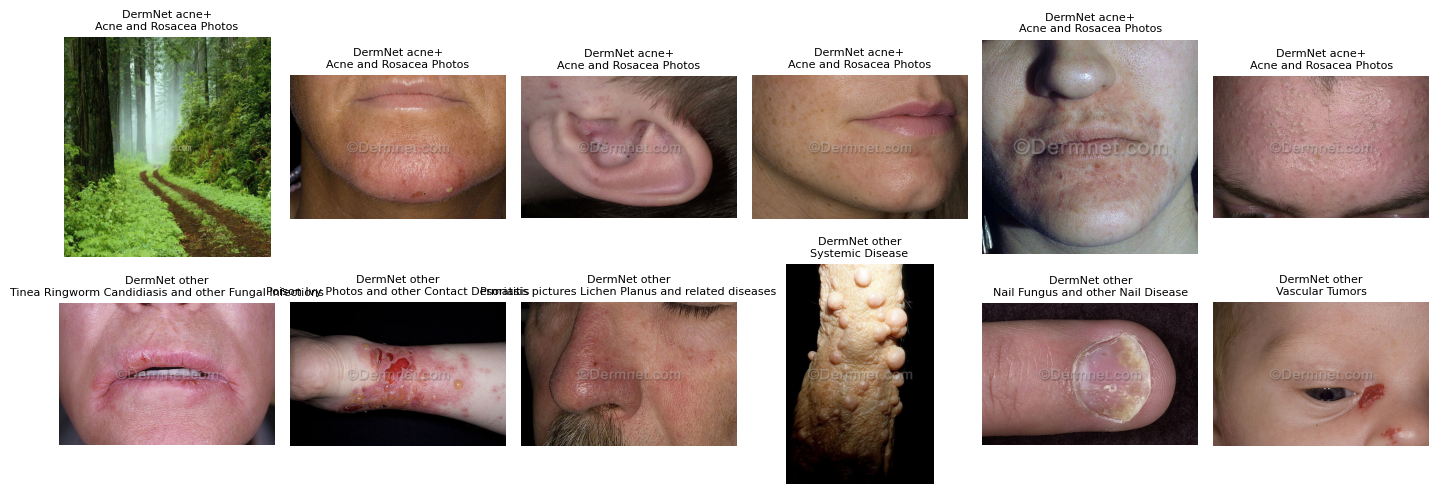

In [7]:
import random
import matplotlib.pyplot as plt
from PIL import Image
from part2_classification.evaluate_dermnet import ACNE_CLASS_KEYWORDS

rng = random.Random(1)
rows = []
for d in sorted(TEST_DIR.iterdir()):
    if not d.is_dir():
        continue
    label = 1 if any(k in d.name.lower() for k in ACNE_CLASS_KEYWORDS) else 0
    imgs = [p for p in d.iterdir() if p.suffix.lower() in {'.jpg', '.jpeg', '.png', '.bmp'}]
    rows.append((d.name, label, len(imgs), imgs))

print('DermNet test class audit:')
for name, label, n, _ in rows:
    print(f"{'[acne+]' if label else '[other]':8} {n:4d}  {name}")
print('total acne+:', sum(n for _, label, n, _ in rows if label))
print('total other :', sum(n for _, label, n, _ in rows if not label))

pos_paths = [p for _, label, _, imgs in rows if label for p in imgs]
neg_paths = [p for _, label, _, imgs in rows if not label for p in imgs]
fig, axes = plt.subplots(2, 6, figsize=(14, 5))
for row_i, (label_name, paths) in enumerate([('DermNet acne+', pos_paths), ('DermNet other', neg_paths)]):
    sample = rng.sample(paths, min(6, len(paths)))
    for ax, p in zip(axes[row_i], sample):
        ax.imshow(Image.open(p).convert('RGB'))
        ax.set_title(f'{label_name}\n{p.parent.name}', fontsize=8)
        ax.axis('off')
plt.tight_layout()

## 4. Train classifier on ACNE04

**Model:** ResNet-50 (ImageNet pretrained) + 2-class head. Heavy albumentations during training; best checkpoint by **val AUROC**.

In [8]:
from part2_classification.train_classifier import train as train_clf
# Tier-1 training upgrades:
#   - color_shortcut_break=True : adds ToGray + ChannelShuffle + RGBShift
#     so the model cannot rely on 'red blob = acne' as its decision feature
#   - source_da_method='reinhard' + dermnet_train_root : Reinhard-normalize
#     ~50% of ACNE04 training crops toward a 20-image DermNet reference
#     mosaic so the source pixel distribution overlaps the target one
#     during training (label-blind sampling of the 20 imgs per the brief)
best_weights = train_clf(
    patches_root='data/acne04_patches',
    out_dir='outputs/classifier',
    backbone='resnet50',
    epochs=15,
    heavy_da=True,
    color_shortcut_break=True,
    source_da_method='reinhard',
    dermnet_train_root='data/dermnet/train',
    source_da_p=0.5,
)
best_weights


[source-DA] applying reinhard with prob=0.50 during training, reference built from 20 label-blind DermNet train imgs
train patches: 186545  |  val patches: 16118
Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 211MB/s]


epoch 01  loss 0.1655  val_acc 0.9671  val_auroc 0.9942
  -> new best val AUROC 0.9942
epoch 02  loss 0.1165  val_acc 0.9674  val_auroc 0.9928
epoch 03  loss 0.1003  val_acc 0.9723  val_auroc 0.9949
  -> new best val AUROC 0.9949
epoch 04  loss 0.0885  val_acc 0.9682  val_auroc 0.9934
epoch 05  loss 0.0801  val_acc 0.9712  val_auroc 0.9949
  -> new best val AUROC 0.9949
epoch 06  loss 0.0710  val_acc 0.9687  val_auroc 0.9940
epoch 07  loss 0.0621  val_acc 0.9726  val_auroc 0.9945
epoch 08  loss 0.0544  val_acc 0.9694  val_auroc 0.9941
epoch 09  loss 0.0456  val_acc 0.9679  val_auroc 0.9939
epoch 10  loss 0.0405  val_acc 0.9704  val_auroc 0.9936
epoch 11  loss 0.0338  val_acc 0.9729  val_auroc 0.9941
epoch 12  loss 0.0293  val_acc 0.9717  val_auroc 0.9941
epoch 13  loss 0.0253  val_acc 0.9712  val_auroc 0.9942
epoch 14  loss 0.0243  val_acc 0.9712  val_auroc 0.9940
epoch 15  loss 0.0227  val_acc 0.9710  val_auroc 0.9941
[classifier] best AUROC = 0.9949, weights at outputs/classifier/bes

PosixPath('outputs/classifier/best.pt')

### ACNE04 patch test-set evaluation

The validation split chooses `best.pt`; this held-out ACNE04 test split is only for a final in-domain patch check.

In [9]:
from pathlib import Path
from torch.utils.data import DataLoader
from part2_classification.dataset import PatchFolder, get_eval_transforms
from part2_classification.train_classifier import evaluate_loader, load_classifier

model = load_classifier(str(best_weights))
test_ds = PatchFolder(PATCH_ROOT / 'test', transform=get_eval_transforms(img_size=224))
test_loader = DataLoader(test_ds, batch_size=64, shuffle=False, num_workers=2, pin_memory=True)
acne04_test_metrics = evaluate_loader(model, test_loader, next(model.parameters()).device)
print('ACNE04 patch test images:', len(test_ds))
acne04_test_metrics

ACNE04 patch test images: 8095


{'acc': 0.9660284126003706, 'auroc': 0.995474439139865}

{'TP': 5034, 'FP': 98, 'TN': 2786, 'FN': 177}


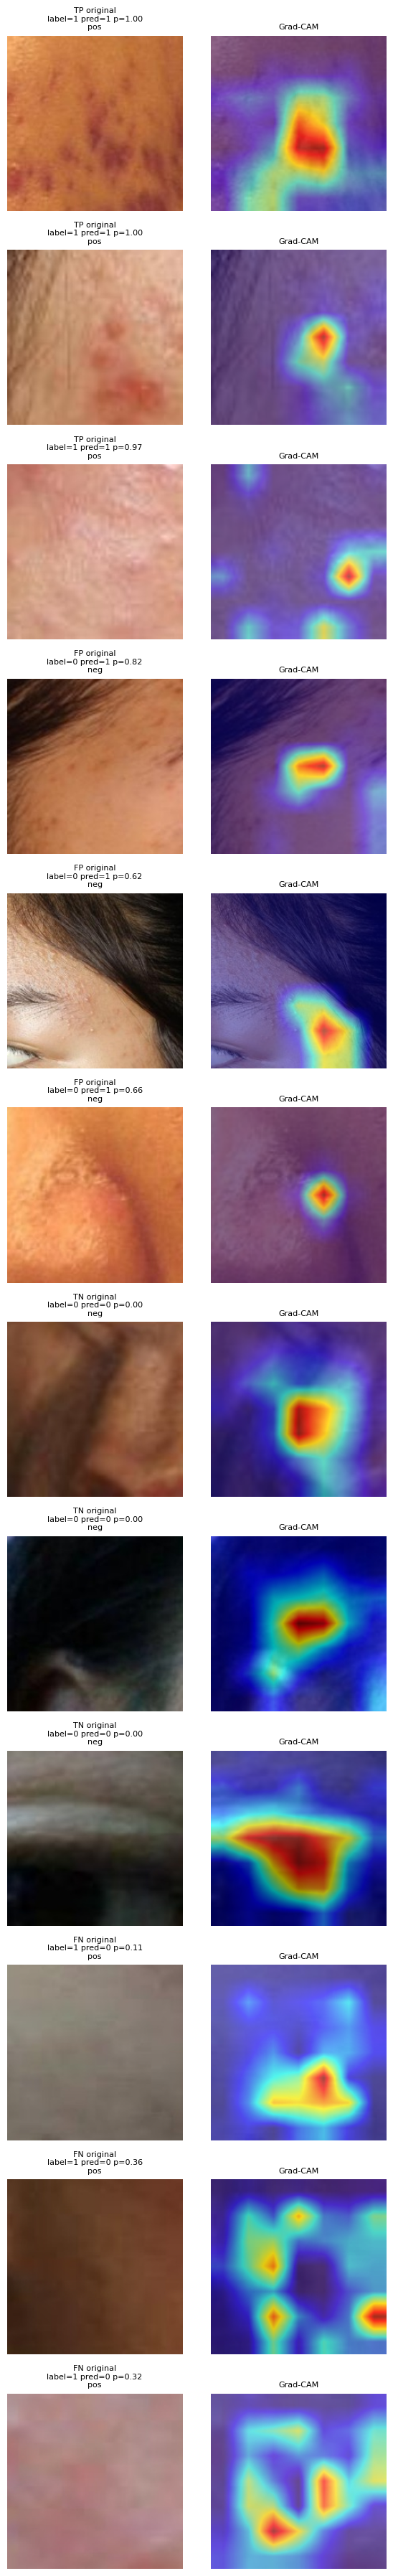

saved outputs/gradcam/acne04_patch_gradcam_grid.png


In [16]:

# Grad-CAM sanity check on ACNE04 patch test predictions
import random
import numpy as np
import torch
import matplotlib.pyplot as plt
from PIL import Image
from pathlib import Path
from torch.utils.data import DataLoader
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.image import show_cam_on_image
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget

from part2_classification.dataset import PatchFolder, get_eval_transforms, IMAGENET_MEAN, IMAGENET_STD
from part2_classification.train_classifier import load_classifier
from part2_classification.model import get_target_layers_for_gradcam

# Load model + ACNE04 test patches
model = load_classifier(str(best_weights))
device = next(model.parameters()).device
model.eval()

test_ds = PatchFolder(PATCH_ROOT / 'test', transform=get_eval_transforms(img_size=224))

# Predict every ACNE04 test patch and keep paths/labels/probs
rows = []
loader = DataLoader(test_ds, batch_size=64, shuffle=False, num_workers=2)
idx0 = 0
with torch.no_grad():
    for x, y in loader:
        x = x.to(device)
        logits = model(x)
        probs = torch.softmax(logits, dim=1)[:, 1].cpu().numpy()
        preds = (probs >= 0.5).astype(int)
        for j in range(len(y)):
            path, label = test_ds.samples[idx0 + j]
            rows.append({
                'path': str(path),
                'label': int(label),
                'prob_acne': float(probs[j]),
                'pred': int(preds[j]),
            })
        idx0 += len(y)

# Stratify TP/FP/TN/FN
bins = {'TP': [], 'FP': [], 'TN': [], 'FN': []}
for r in rows:
    if r['label'] == 1 and r['pred'] == 1:
        bins['TP'].append(r)
    elif r['label'] == 0 and r['pred'] == 1:
        bins['FP'].append(r)
    elif r['label'] == 0 and r['pred'] == 0:
        bins['TN'].append(r)
    else:
        bins['FN'].append(r)

print({k: len(v) for k, v in bins.items()})

# Pick examples: 3 from each bin if available
rng = random.Random(0)
selected = []
for k in ['TP', 'FP', 'TN', 'FN']:
    rng.shuffle(bins[k])
    selected.extend([(k, r) for r in bins[k][:3]])

# Helpers
mean = np.array(IMAGENET_MEAN)
std = np.array(IMAGENET_STD)
def denorm(x):
    arr = x.detach().cpu().numpy().transpose(1, 2, 0)
    arr = arr * std + mean
    return np.clip(arr, 0, 1)

# Grad-CAM
cam = GradCAM(model=model, target_layers=get_target_layers_for_gradcam(model))
eval_tf = get_eval_transforms(img_size=224)

n = len(selected)
fig, axes = plt.subplots(n, 2, figsize=(6, 3*n))
if n == 1:
    axes = np.array([axes])

for i, (kind, row) in enumerate(selected):
    raw = np.array(Image.open(row['path']).convert('RGB'))
    x = eval_tf(image=raw)['image'].unsqueeze(0).to(device)
    target_class = row['pred']  # explain predicted class
    grayscale_cam = cam(input_tensor=x, targets=[ClassifierOutputTarget(target_class)])[0]
    rgb = denorm(x[0])
    overlay = show_cam_on_image(rgb, grayscale_cam, use_rgb=True)

    axes[i, 0].imshow(raw)
    axes[i, 0].set_title(f"{kind} original\nlabel={row['label']} pred={row['pred']} p={row['prob_acne']:.2f}\n{Path(row['path']).parent.name}", fontsize=8)
    axes[i, 0].axis('off')

    axes[i, 1].imshow(overlay)
    axes[i, 1].set_title('Grad-CAM', fontsize=8)
    axes[i, 1].axis('off')

plt.tight_layout()
out_path = 'outputs/gradcam/acne04_patch_gradcam_grid.png'
Path(out_path).parent.mkdir(parents=True, exist_ok=True)
plt.savefig(out_path, dpi=150, bbox_inches='tight')
plt.show()
print('saved', out_path)


## 5. Domain-gap ablation on DermNet

In [10]:
from part2_classification.evaluate_dermnet import evaluate as eval_dermnet
import pandas as pd

table = {}
for da, tta, eval_mode, agg, name in [
    ('none', False, 'full', 'top3_mean', 'baseline_full'),
    ('histogram', False, 'full', 'top3_mean', '+histogram_full'),
    ('reinhard', False, 'full', 'top3_mean', '+reinhard_full'),
    ('reinhard', True, 'full', 'top3_mean', '+reinhard+TTA_full'),
    # Multi-crop evaluates each DermNet image as a small bag of deterministic
    # local crops, then aggregates crop scores. This better matches the patch
    # classifier than resizing the entire clinical image into one 224x224 input.
    ('none', False, 'multicrop', 'top3_mean', 'baseline_multicrop_top3'),
    ('none', False, 'multicrop', 'max', 'baseline_multicrop_max'),
    ('reinhard', True, 'multicrop', 'top3_mean', '+reinhard+TTA_multicrop_top3'),
]:
    safe_name = name.replace('+','').replace(' ','_')
    table[name] = eval_dermnet(
        weights=str(best_weights),
        dermnet_root='data/dermnet',
        da_method=da,
        tta=tta,
        eval_mode=eval_mode,
        multicrop_agg=agg,
        out_dir=f'outputs/dermnet_eval/{safe_name}',
    )
pd.DataFrame(table).T[['acc', 'f1', 'auroc', 'eval_mode', 'multicrop_agg']]


[DA] no preprocessing applied
DermNet test images: 4002
{
  "n": 4002,
  "acc": 0.8120939530234883,
  "f1": 0.1772428884026258,
  "auroc": 0.6407081682996317,
  "confusion_matrix": [
    [
      3169,
      521
    ],
    [
      231,
      81
    ]
  ],
  "da_method": "none",
  "tta": false,
  "eval_mode": "full",
  "multicrop_agg": null
}
[DA] using histogram with reference from 20 DermNet train imgs
DermNet test images: 4002
{
  "n": 4002,
  "acc": 0.8180909545227386,
  "f1": 0.15151515151515152,
  "auroc": 0.6178284170662218,
  "confusion_matrix": [
    [
      3209,
      481
    ],
    [
      247,
      65
    ]
  ],
  "da_method": "histogram",
  "tta": false,
  "eval_mode": "full",
  "multicrop_agg": null
}
[DA] using reinhard with reference from 20 DermNet train imgs
DermNet test images: 4002
{
  "n": 4002,
  "acc": 0.8070964517741129,
  "f1": 0.16989247311827957,
  "auroc": 0.6242582169411438,
  "confusion_matrix": [
    [
      3151,
      539
    ],
    [
      233,
      7

,acc,f1,auroc,eval_mode,multicrop_agg
baseline_full,0.812094,0.177243,0.640708,full,None
+histogram_full,0.818091,0.151515,0.617828,full,None
+reinhard_full,0.807096,0.169892,0.624258,full,None
+reinhard+TTA_full,0.804098,0.158798,0.628221,full,None
baseline_multicrop_top3,0.622189,0.207547,0.687265,multicrop,top3_mean
baseline_multicrop_max,0.491504,0.190211,0.680162,multicrop,max
+reinhard+TTA_multicrop_top3,0.628686,0.206197,0.680362,multicrop,top3_mean


## 6. Grad-CAM on 10 DermNet predictions

Each selected DermNet example is shown as an **untouched original** next to the Grad-CAM overlay. The heatmap still uses the same preprocessing as evaluation (`da_method='reinhard'`) so it explains what the model saw.

saved tuned predictions: outputs/dermnet_eval/baseline_multicrop_top3/predictions_thr093.json
saved outputs/gradcam/gradcam_grid.png


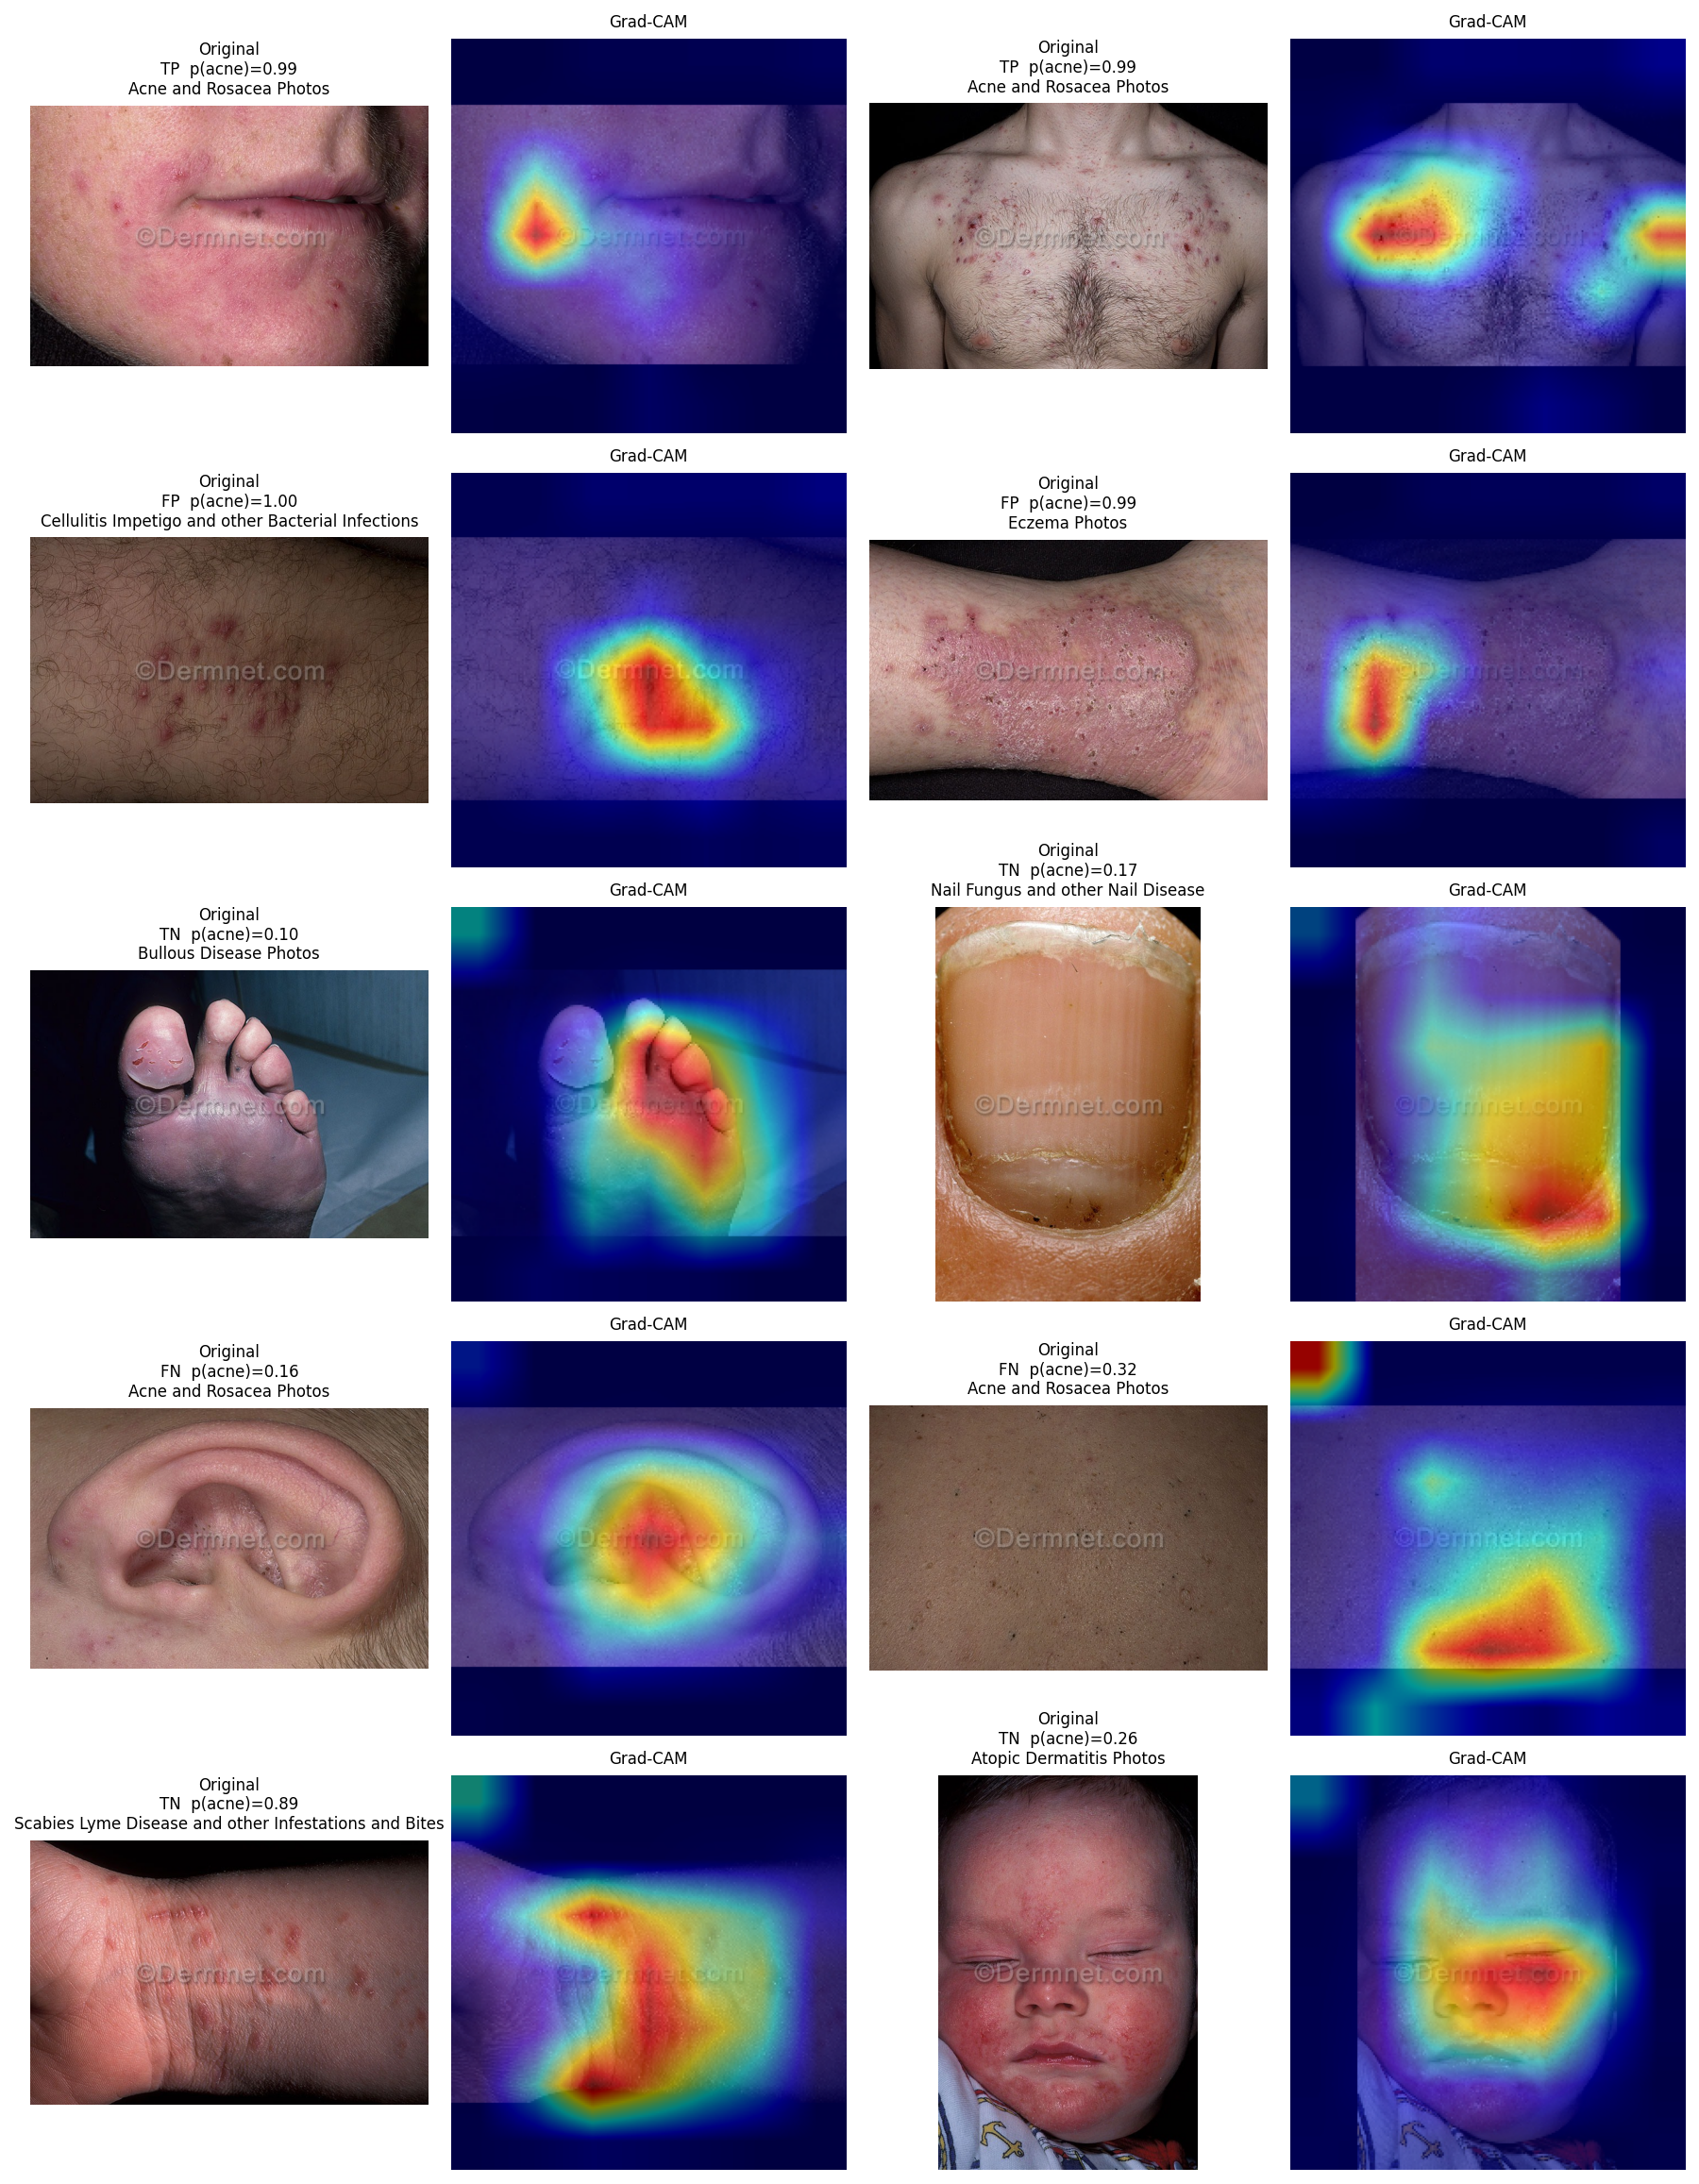

In [17]:
from part2_classification.gradcam import visualize_gradcam
from IPython.display import Image as IPyImage

out = visualize_gradcam(
    weights=str(best_weights),
    predictions_json='outputs/dermnet_eval/reinhardTTA/predictions.json',
    dermnet_train_root='data/dermnet/train',
    da_method='reinhard',
    n_samples=10,
    show_original=True,
)
IPyImage(filename=str(out))